### Carrega o dataset MNIST usando o Keras

In [1]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

### Normalizacao das imagens (intervalo [0, 1])

In [2]:
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

### One hot enconding nos rótulos

In [3]:
# Sobre o nível para a raiz do projeto, para conseguir importar funcoes do /mlp
import sys
sys.path.append('..')

from mlp.losses import one_hot

y_train = one_hot(y_train)
y_test = one_hot(y_test)

### Treino e Plots

In [6]:
from mlp.network import MLP
from mlp.optimizers import SGD

configs = [
    {"lr": 0.01, "label": "lr=0.01"},
    {"lr": 0.05,  "label": "lr=0.05"},
]

def train_mlp(lr):
    mlp = MLP([784, 128, 64, 10])
    optimizer = SGD(lr=lr)
    mlp.fit(X_train, y_train, optimizer, epochs=20, batch_size=64, X_val=X_test, y_val=y_test)
    print(f"Acurácia no teste: {mlp.accuracy(X_test, y_test):.4f}")
    return mlp

mlp_1 = train_mlp(configs[0]['lr'])
mlp_2 = train_mlp(configs[1]['lr'])

Epoch 1/20 - Loss: 2.3040 - Acc: 0.1124 - Val Loss: 2.3005 - Val Acc: 0.1135
Epoch 2/20 - Loss: 2.3020 - Acc: 0.1124 - Val Loss: 2.2972 - Val Acc: 0.1135
Epoch 3/20 - Loss: 2.2783 - Acc: 0.2083 - Val Loss: 2.1968 - Val Acc: 0.2091
Epoch 4/20 - Loss: 1.9503 - Acc: 0.4867 - Val Loss: 1.5465 - Val Acc: 0.4827
Epoch 5/20 - Loss: 1.1569 - Acc: 0.6916 - Val Loss: 0.9265 - Val Acc: 0.6932
Epoch 6/20 - Loss: 0.7826 - Acc: 0.7859 - Val Loss: 0.6548 - Val Acc: 0.7916
Epoch 7/20 - Loss: 0.6212 - Acc: 0.8300 - Val Loss: 0.5521 - Val Acc: 0.8357
Epoch 8/20 - Loss: 0.5190 - Acc: 0.8650 - Val Loss: 0.4605 - Val Acc: 0.8667
Epoch 9/20 - Loss: 0.4414 - Acc: 0.8824 - Val Loss: 0.4110 - Val Acc: 0.8816
Epoch 10/20 - Loss: 0.3968 - Acc: 0.8911 - Val Loss: 0.3725 - Val Acc: 0.8883
Epoch 11/20 - Loss: 0.3653 - Acc: 0.8991 - Val Loss: 0.3477 - Val Acc: 0.8980
Epoch 12/20 - Loss: 0.3390 - Acc: 0.9082 - Val Loss: 0.3192 - Val Acc: 0.9077
Epoch 13/20 - Loss: 0.3164 - Acc: 0.9140 - Val Loss: 0.2994 - Val Acc: 0.

### Plots 

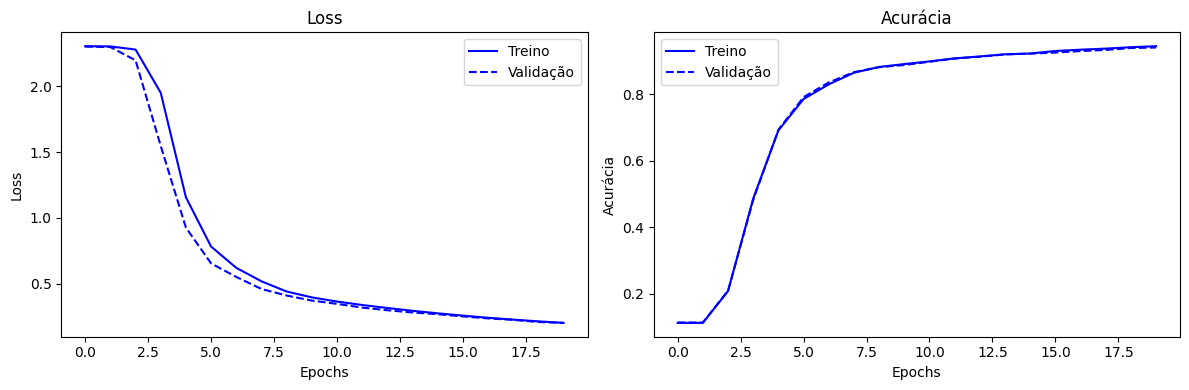

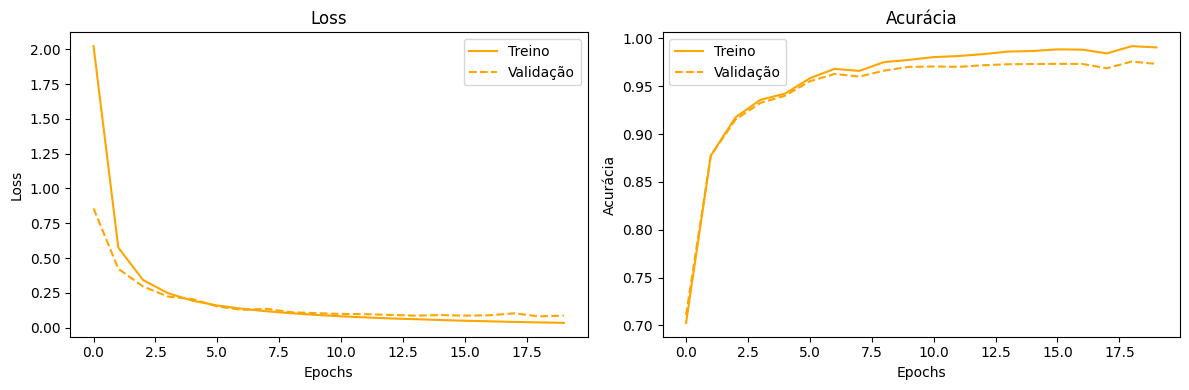

In [7]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(mlp, number=1, color='blue'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(mlp.history_loss, label='Treino', color=color)
    ax1.plot(mlp.history_val_loss, label='Validação', color=color, linestyle='--')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(mlp.history_acc, label='Treino', color=color)
    ax2.plot(mlp.history_val_acc, label='Validação', color=color, linestyle='--')
    ax2.set_title('Acurácia')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Acurácia')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'../results/loss_accuracy_{number}.png')
    plt.show()

plot_loss_accuracy(mlp_1, number=1, color='blue')
plot_loss_accuracy(mlp_2, number=2, color='orange')